In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ( SimpleExpSmoothing, Holt, ExponentialSmoothing)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv(r'C:\Users\MINA\Documents\WeekilyPrac\Ml_JOUNRAL\ml-learning-journal\Time Series\SARIMA\monthly_sales.csv')

In [4]:
df.head()

,Date,Sales
0,2020-01-31,120
1,2020-02-29,118
2,2020-03-31,125
3,2020-04-30,132
4,2020-05-31,138


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [6]:
df.head()

,Sales
Date,
2020-01-31,120
2020-02-29,118
2020-03-31,125
2020-04-30,132
2020-05-31,138


In [7]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2020-01-31 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   60 non-null     int64
dtypes: int64(1)
memory usage: 960.0 bytes


In [8]:
df.isnull().sum()

Sales    0
dtype: int64

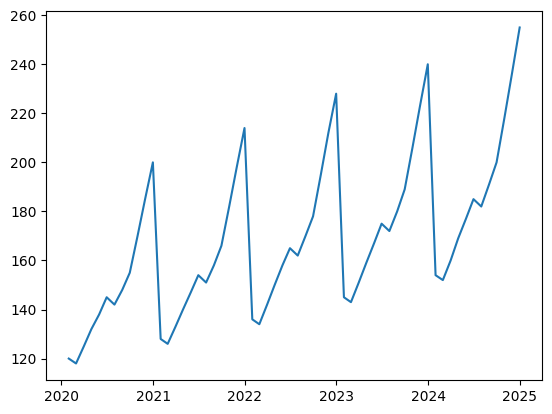

In [9]:
plt.plot(df['Sales'])
plt.show()

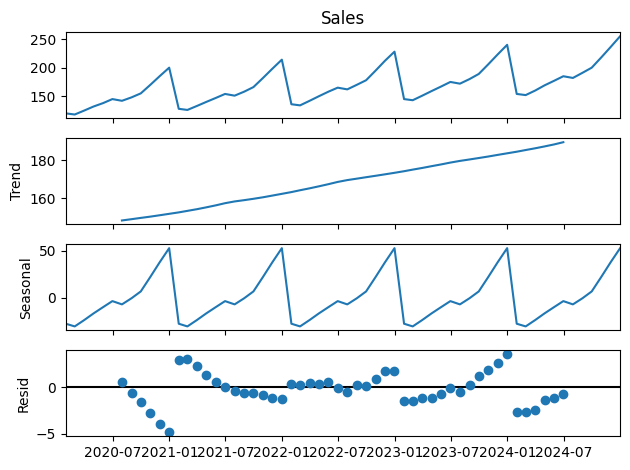

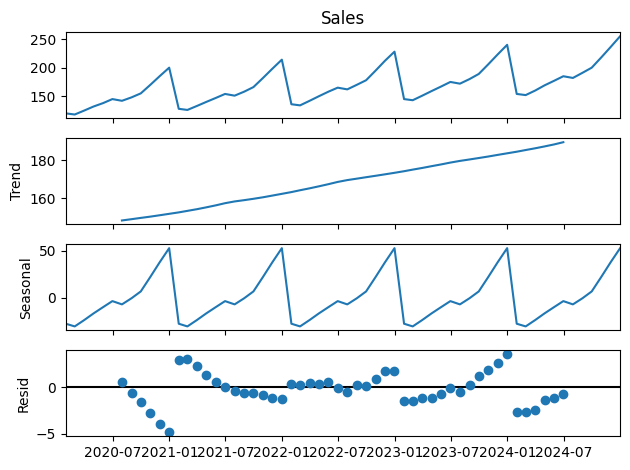

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['Sales'],model='additive', period=12)
decompose.plot()

In [11]:
train = df.iloc[:-12]
test = df.iloc[-12:]

In [12]:
hw_model = ExponentialSmoothing(
    train['Sales'], trend='add', seasonal='add', seasonal_periods=12
).fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [13]:
hw_forecast = hw_model.forecast(12)

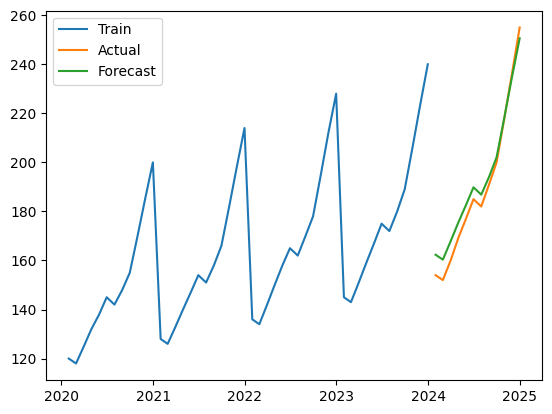

In [15]:
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, hw_forecast, label='Forecast')

plt.legend()
plt.show()

In [16]:
mae = mean_absolute_error(test["Sales"], hw_forecast)

rmse = np.sqrt(mean_squared_error(test["Sales"], hw_forecast))

print("MAE :", mae)

print("RMSE :", rmse)

MAE : 4.784723231777337
RMSE : 5.429329176753317
